# Klasifikasi Penyakit Buah Kakao (Versi Sederhana)

Alur: Import → Eksplorasi Data → Split Train/Val → Balancing Kelas → Augmentasi → Data Generator → Bangun Model (EfficientNetB0) → Training → Evaluasi → Grad-CAM

## 1. Import Library

In [13]:
import os, shutil, math, time
from random import sample

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
import Augmentor

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")


In [14]:
import random
import numpy as np
import tensorflow as tf


SEED = 123

# 2. Kunci seed untuk bawaan Python & NumPy
random.seed(SEED)
np.random.seed(SEED)

# 3. Kunci seed untuk TensorFlow (mengunci inisialisasi bobot & dropout)
tf.random.set_seed(SEED)

# 4. Aktifkan determinisme TensorFlow (Sangat penting untuk TF versi >= 2.9)
# Ini memaksa semua operasi GPU/CPU berjalan dengan urutan yang sama persis
tf.config.experimental.enable_op_determinism()

## 2. Konfigurasi
Semua path dan hyperparameter dikumpulkan di satu tempat agar mudah diubah.

In [15]:
DATASET_PATH   = "cacao_photos"        # folder dataset asli (belum displit)
TRAIN_PATH     = "./trains"
VAL_PATH       = "./testt"
BEST_MODEL_DIR = "./best_models"
CLASSES        = ["black_pod_rot", "healthy", "pod_borer"]

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16          # sebelumnya 1 -> dinaikkan agar training lebih cepat & stabil
EPOCHS     = 30
VAL_RATIO  = 0.20
LEARNING_RATE = 1e-4



## 3. Eksplorasi Data Awal
Menghitung jumlah gambar tiap kelas pada dataset mentah.

In [16]:
for c in CLASSES:
    jumlah = len(os.listdir(f"{DATASET_PATH}/{c}"))
    print(f"{c:15s}: {jumlah} gambar")


black_pod_rot  : 943 gambar
healthy        : 3344 gambar
pod_borer      : 103 gambar


In [17]:
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
for c in CLASSES:
    os.makedirs(f"{VAL_PATH}/{c}", exist_ok=True)

if not os.listdir(TRAIN_PATH):
    for c in CLASSES:
        shutil.copytree(f"{DATASET_PATH}/{c}", f"{TRAIN_PATH}/{c}")
    print("Dataset berhasil disalin ke train_photos.")
else:
    print("train_photos sudah terisi, proses salin dilewati.")


train_photos sudah terisi, proses salin dilewati.


In [18]:
# 1. Tentukan nama file indikator (bisa ditaruh di folder utama dataset Anda)
INDIKATOR_FILE = "splits_selesai.marker"

def pindahkan_sebagian(sumber, tujuan, jumlah):
    """Pindahkan sejumlah file pertama dari folder sumber ke folder tujuan."""
    # Pastikan folder tujuan sudah dibuat, jika belum akan dibuat otomatis
    os.makedirs(tujuan, exist_ok=True)
    
    # Jika folder tujuan sudah berisi data, lewati folder ini (anti-double split per class)
    if os.listdir(tujuan):
        print(f"Folder {tujuan} sudah terisi, melewati...")
        return
        
    for file in os.listdir(sumber)[:jumlah]:
        shutil.move(os.path.join(sumber, file), os.path.join(tujuan, file))

# 2. Cek apakah file indikator sudah ada dari running sebelumnya
if os.path.exists(INDIKATOR_FILE):
    print("Maju logis: Proses split train/val sudah pernah dilakukan sebelumnya. Langkah ini dilewati.")
else:
    print("Memulai proses split train/val untuk pertama kalinya...")
    
    for c in CLASSES:
        sumber_dir = f"{TRAIN_PATH}/{c}"
        tujuan_dir = f"{VAL_PATH}/{c}"
        
        # Pastikan folder sumber ada sebelum melakukan listdir
        if os.path.exists(sumber_dir):
            jumlah_val = math.ceil(len(os.listdir(sumber_dir)) * VAL_RATIO)
            pindahkan_sebagian(sumber_dir, tujuan_dir, jumlah_val)
    
    # 3. Buat file indikator setelah seluruh loop kelas selesai dengan sukses
    with open(INDIKATOR_FILE, "w") as f:
        f.write("Proses split data berhasil dilakukan.")
        
    print("Split train/val selesai dan file indikator telah dibuat.")

Maju logis: Proses split train/val sudah pernah dilakukan sebelumnya. Langkah ini dilewati.


## 6. Balancing Kelas Healthy
Jumlah kelas *Healthy* biasanya jauh lebih banyak dari *Black Pod Rot*, sehingga sebagian gambarnya dihapus secara acak agar jumlahnya seimbang dengan *Black Pod Rot*.

In [19]:
# 1. Tentukan nama file indikator khusus untuk balancing
INDIKATOR_BALANCING = "balancings_selesai.marker"

# 2. Cek apakah proses balancing sudah pernah dilakukan sebelumnya
if os.path.exists(INDIKATOR_BALANCING):
    print("Maju logis: Dataset sudah diseimbangkan pada running sebelumnya. Langkah ini dilewati.")
else:
    print("Memulai proses balancing data...")
    
    # Pastikan path folder benar dan ada
    path_black = f"{TRAIN_PATH}/black_pod_rot"
    path_healthy = f"{TRAIN_PATH}/healthy"
    
    if os.path.exists(path_black) and os.path.exists(path_healthy):
        n_black   = len(os.listdir(path_black))
        n_healthy = len(os.listdir(path_healthy))

        if n_healthy > n_black:
            file_dihapus = sample(os.listdir(path_healthy), n_healthy - n_black)
            for f in file_dihapus:
                os.remove(f"{path_healthy}/{f}")
            print(f"{len(file_dihapus)} gambar Healthy dihapus untuk balancing.")
        else:
            print("Kelas Healthy sudah seimbang, tidak ada file yang dihapus.")
            
        # 3. Buat file indikator setelah proses pengecekan/penghapusan selesai
        with open(INDIKATOR_BALANCING, "w") as f:
            f.write("Proses balancing selesai.")
        print("File indikator balancing telah dibuat.")
        
    else:
        print("Error: Folder train untuk black_pod_rot atau healthy tidak ditemukan!")

Maju logis: Dataset sudah diseimbangkan pada running sebelumnya. Langkah ini dilewati.


In [20]:
print(TRAIN_PATH)
print(os.listdir(TRAIN_PATH))
print(os.listdir(os.path.join(TRAIN_PATH, "pod_borer")))

./trains
['black_pod_rot', 'healthy', 'pod_borer']
['pod_borer_25.jpg', 'pod_borer_26.jpg', 'pod_borer_27.jpg', 'pod_borer_28.jpg', 'pod_borer_29.jpg', 'pod_borer_3.jpg', 'pod_borer_30.jpg', 'pod_borer_31.jpg', 'pod_borer_32.jpg', 'pod_borer_33.jpg', 'pod_borer_34.jpg', 'pod_borer_35.jpg', 'pod_borer_36.jpg', 'pod_borer_37.jpg', 'pod_borer_38.jpg', 'pod_borer_39.jpg', 'pod_borer_4.jpg', 'pod_borer_40.jpg', 'pod_borer_41.jpg', 'pod_borer_42.jpg', 'pod_borer_43.jpg', 'pod_borer_44.jpg', 'pod_borer_45.jpg', 'pod_borer_46.jpg', 'pod_borer_47.jpg', 'pod_borer_48.jpg', 'pod_borer_49.jpg', 'pod_borer_5.jpg', 'pod_borer_50.jpg', 'pod_borer_51.jpg', 'pod_borer_52.jpg', 'pod_borer_53.jpg', 'pod_borer_54.jpg', 'pod_borer_55.jpg', 'pod_borer_56.jpg', 'pod_borer_57.jpg', 'pod_borer_58.jpg', 'pod_borer_59.jpg', 'pod_borer_6.jpg', 'pod_borer_60.jpg', 'pod_borer_61.jpg', 'pod_borer_62.jpg', 'pod_borer_63.jpg', 'pod_borer_64.jpg', 'pod_borer_65.jpg', 'pod_borer_66.jpg', 'pod_borer_67.jpg', 'pod_borer_6

## 8. Data Generator
Membaca gambar langsung dari folder `train_photos` dan `val_photos` dalam format yang bisa dibaca model.

In [21]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_generator = datagen.flow_from_directory(
    TRAIN_PATH, 
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, 
    class_mode="sparse",
    seed=SEED) # <-- TAMBAHKAN PARAMETER INI

val_generator = datagen.flow_from_directory(
    VAL_PATH, 
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, 
    class_mode="sparse", 
    shuffle=False)

Found 1590 images belonging to 3 classes.


Found 879 images belonging to 3 classes.


## 9. Bangun Model (Transfer Learning EfficientNetB0)
Menggunakan EfficientNetB0 sebagai base model, lalu ditambah `GlobalAveragePooling2D` + `Dropout` + `Dense(3, softmax)` di atasnya.

In [22]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, input_shape=train_generator.image_shape)

base_model.trainable = False
for layer in base_model.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True    # hampir semua layer ikut dilatih ulang, kecuali BatchNorm

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(3, activation="softmax")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)
model.compile(
    loss=tf.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=[tf.metrics.SparseCategoricalAccuracy()]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,969,375 (15.14 MB)

 Non-trainable params: 84,039 (328.28 KB)

## 10. Training Model
Menggunakan `EarlyStopping` (berhenti jika val_loss tidak membaik 4 epoch berturut-turut) dan `ModelCheckpoint` (menyimpan model dengan val_loss terbaik).

In [23]:
# Tentukan path penyimpanan model di akhir
checkpoint_path = f"{BEST_MODEL_DIR}/best_tanpa_augmentasi.keras"

callbacks = [
    # KUNCI: restore_best_weights=True ditambahkan agar model otomatis kembali ke performa terbaiknya
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        mode="min", 
        patience=8, 
        restore_best_weights=True
    )
]

# Mulai training
waktu_mulai = time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)
waktu_selesai = time.time()

# --- PROSES SIMPAN MODEL TERBAIK SETELAH TRAINING SELESAI ---
print("\n[INFO] Training selesai. Menyimpan model terbaik...")
model.save(checkpoint_path)
print(f"[SUKSES] Model terbaik telah disimpan di: {checkpoint_path}\n")
# ------------------------------------------------------------

# Cetak Ringkasan Eksperimen
durasi_detik  = waktu_selesai - waktu_mulai
epoch_jalan   = len(history.history["loss"])
print(f"Total waktu training : {durasi_detik/60:.1f} menit ({durasi_detik:.0f} detik)")
print(f"Epoch berjalan       : {epoch_jalan} dari {EPOCHS} (berhenti lebih awal jika EarlyStopping aktif)")
print(f"Rata-rata per epoch  : {durasi_detik/epoch_jalan:.1f} detik")

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - loss: 0.5032 - sparse_categorical_accuracy: 0.7843 - val_loss: 0.1961 - val_sparse_categorical_accuracy: 0.9261
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - loss: 0.1803 - sparse_categorical_accuracy: 0.9346 - val_loss: 0.1601 - val_sparse_categorical_accuracy: 0.9374
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - loss: 0.1034 - sparse_categorical_accuracy: 0.9616 - val_loss: 0.1897 - val_sparse_categorical_accuracy: 0.9295
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - loss: 0.0437 - sparse_categorical_accuracy: 0.9874 - val_loss: 0.1538 - val_sparse_categorical_accuracy: 0.9534
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - loss: 0.0315 - sparse_categorical_accuracy: 0.9918 - val_loss: 0.1556 - val_sparse_categorical_accuracy: 0.9613
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - loss: 0.0234 - sparse_categorical_accuracy: 0.9931 - val_loss: 0.1907 - val_sparse_categorical_accuracy: 0.951

## 11. Evaluasi Model Terbaik
Memuat model dengan val_loss terendah, lalu menampilkan confusion matrix dan classification report.

55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 696ms/step


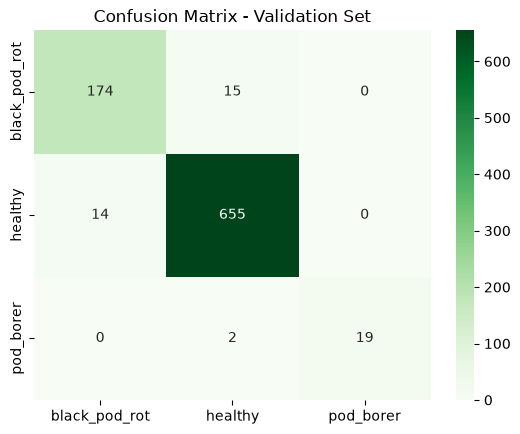

               precision    recall  f1-score   support

black_pod_rot       0.93      0.92      0.92       189
      healthy       0.97      0.98      0.98       669
    pod_borer       1.00      0.90      0.95        21

     accuracy                           0.96       879
    macro avg       0.97      0.93      0.95       879
 weighted avg       0.96      0.96      0.96       879



In [24]:
best_model = tf.keras.models.load_model(checkpoint_path)

val_pred = best_model.predict(val_generator)
val_pred_classes = np.argmax(val_pred, axis=1)
val_true_classes = val_generator.classes

cm_result = confusion_matrix(val_true_classes, val_pred_classes)
sns.heatmap(cm_result, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix - Validation Set")
plt.show()

print(classification_report(val_true_classes, val_pred_classes, target_names=CLASSES))


## 12. Kurva Akurasi & Loss

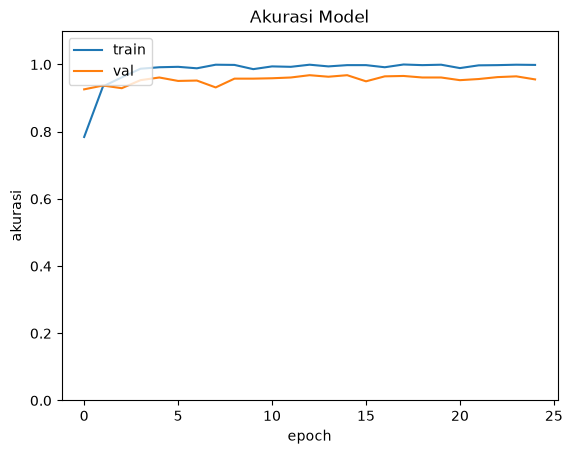

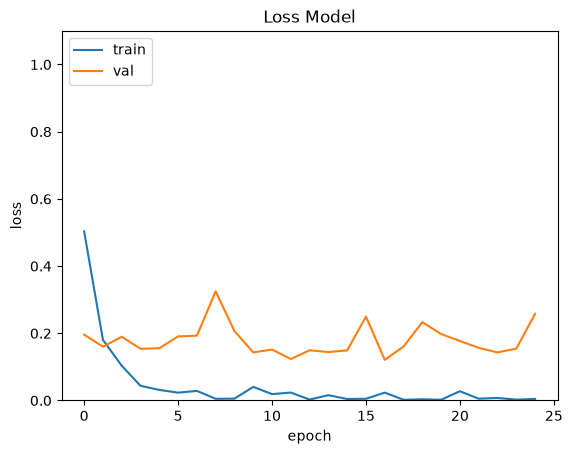

In [25]:
def plot_kurva(kunci_train, kunci_val, judul, ylabel):
    plt.plot(history.history[kunci_train])
    plt.plot(history.history[kunci_val])
    plt.title(judul)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.ylim(0, 1.1)
    plt.legend(["train", "val"], loc="upper left")
    plt.show()

plot_kurva("sparse_categorical_accuracy", "val_sparse_categorical_accuracy",
           "Akurasi Model", "akurasi")
plot_kurva("loss", "val_loss", "Loss Model", "loss")


In [26]:
import pandas as pd

# Mengambil nilai pada epoch terakhir
train_acc = history.history['sparse_categorical_accuracy'][-1]
val_acc = history.history['val_sparse_categorical_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

ringkasan = pd.DataFrame({
    "Parameter": [
        "Ukuran Gambar",
        "Batch Size",
        "Learning Rate",
        "Optimizer",
        "Epoch",
        "Jumlah Data Training",
        "Jumlah Data Validasi",
        "Training Accuracy",
        "Validation Accuracy",
        "Training Loss",
        "Validation Loss",
        "Total Waktu Training",
        "Rata-rata Waktu / Epoch"
    ],
    "Nilai": [
        f"{IMG_HEIGHT} x {IMG_WIDTH}",
        BATCH_SIZE,
        LEARNING_RATE,
        "Adam",
        f"{epoch_jalan}/{EPOCHS}",
        train_generator.samples,
        val_generator.samples,
        f"{train_acc*100:.2f} %",
        f"{val_acc*100:.2f} %",
        f"{train_loss:.4f}",
        f"{val_loss:.4f}",
        f"{durasi_detik/60:.2f} menit",
        f"{durasi_detik/epoch_jalan:.2f} detik"
    ]
})

display(ringkasan)

,Parameter,Nilai
0,Ukuran Gambar,224 x 224
1,Batch Size,16
2,Learning Rate,0.0001
3,Optimizer,Adam
4,Epoch,25/30
5,Jumlah Data Training,1590
6,Jumlah Data Validasi,879
7,Training Accuracy,99.87 %
8,Validation Accuracy,95.56 %
9,Training Loss,0.0046


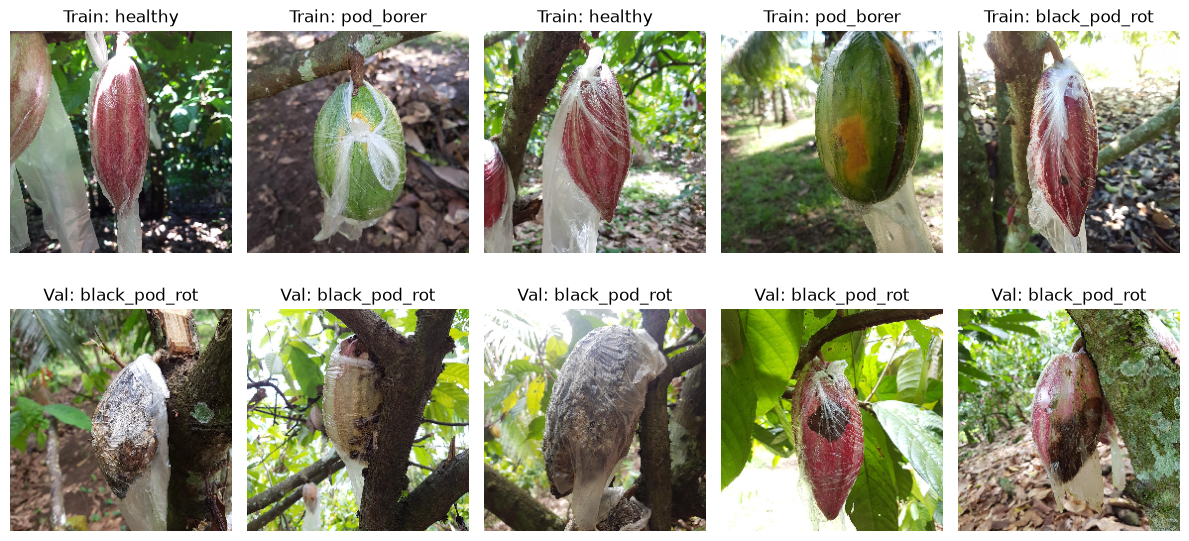

In [27]:
# ====================================================================
# TAMPILKAN 5 DATA TRAIN & 5 DATA VALIDATION (Gambar 4.9)
# ====================================================================

# 1. Ambil satu batch data dari train_generator
train_images, train_labels = next(train_generator) 

plt.figure(figsize=(12, 6)) 

# Tampilkan 5 Gambar Data Train
for i in range(5): 
    ax = plt.subplot(2, 5, i+1) 
    # .astype('uint8') diperlukan karena data bertipe float dalam rentang 0-255
    plt.imshow(train_images[i].astype('uint8')) 
    # Menggunakan variabel CLASSES dan dikonversi ke int karena class_mode="sparse"
    plt.title(f"Train: {CLASSES[int(train_labels[i])]}") 
    plt.axis("off") 

# 2. Ambil satu batch data dari val_generator (di file Anda menggunakan val_generator, bukan test_generator)
val_images, val_labels = next(val_generator) 

# Tampilkan 5 Gambar Data Validation (Test)
for i in range(5): 
    ax = plt.subplot(2, 5, i+6) 
    plt.imshow(val_images[i].astype('uint8')) 
    plt.title(f"Val: {CLASSES[int(val_labels[i])]}") 
    plt.axis("off") 

plt.tight_layout() 
plt.show()

# Gambar 4. 9: Visualisasi Sampel Data Training dan Data Validation